## Veri Hakkında Bilgiler

Bu veri seti (Online Shoppers Purchasing Intention), bir e-ticaret sitesine giren kullanıcıların **satın alma işlemi yapıp yapmayacağını (Revenue)** tahmin etmek üzerine kuruludur.

Değişkenleri mantıksal gruplara ayırarak incelemek, istatistiksel analiz yaparken işinizi çok kolaylaştıracaktır.

İşte sütunların anlamları:

### 1. Sayfa Etkileşimleri (Numerical - Sayısal)
Bu 3 grup değişken, kullanıcının sitedeki davranış yoğunluğunu gösterir. Sizin az önce analiz ettiğiniz (Sayfa Sayısı vs Süre) değişkenler bunlardır.

* **Administrative:** Kullanıcının girdiği "İdari" sayfa sayısı (Örn: Hesap ayarları, şifre değiştirme vb.).
* **Administrative_Duration:** İdari sayfalarda harcanan toplam süre (saniye cinsinden).
* **Informational:** Kullanıcının girdiği "Bilgilendirici" sayfa sayısı (Örn: İletişim, Adres, Hakkımızda).
* **Informational_Duration:** Bilgilendirici sayfalarda harcanan toplam süre.
* **ProductRelated:** Kullanıcının girdiği "Ürün ile ilgili" sayfa sayısı (Örn: Ürün detayları, listeleme sayfaları).
* **ProductRelated_Duration:** Ürün sayfalarında harcanan toplam süre.
    * *Not: Genelde en yüksek varyasyon ve bilgi bu gruptadır çünkü asıl alışveriş burada döner.*

### 2. Google Analytics Metrikleri (Ratio - Oranlar)
Bu kısım veri setinin teknik kalbidir. Kullanıcı davranışının kalitesini ölçer.

* **BounceRates (Hemen Çıkma Oranı):** Bu sütun, kullanıcının o oturumda ziyaret ettiği tüm sayfaların ortalama "Hemen Çıkma Oranı"nı temsil eder. (Bu kullanıcı ne kadar 'sıkıcı/kötü' sayfalarda dolaştı?)
* **ExitRates (Çıkış Oranı):** Kullanıcının gezdiği sayfaların, geçmişte diğer kullanıcılar için ne sıklıkla "Çıkış Kapısı" olduğunun ortalamasıdır. Eğer kullanıcının ExitRates değeri yüksekse, bu kullanıcı genelde insanların oturumu sonlandırdığı sayfalarda dolaşmış demektir.
    * *Farkı:* Bounce Rate tek sayfalık ziyaretler içindir. Exit Rate ise uzun bir gezintinin son durağı olup olmadığını gösterir.
* **PageValues (Sayfa Değeri):** **(En Önemli Özellik!)** Bir kullanıcının e-ticaret işlemini tamamlamadan (satın almadan) önce ziyaret ettiği sayfaların ortalama değeridir.
    * *İpucu:* Eğer bu değer 0 ise, o sayfa hiçbir satış işlemine katkıda bulunmamış demektir. Satın almayı tahminlemede (classification) genelde en belirleyici değişkendir.

### 3. Zaman ve Sezonsallık (Categorical/Numerical)
* **SpecialDay:** Ziyaretin özel bir güne (Anneler Günü, Sevgililer Günü vb.) yakınlığını belirtir.
    * *Değer:* 0 ile 1 arasındadır. 1'e ne kadar yakınsa, özel güne o kadar yakındır (veya o gündür).
* **Month:** Ziyaretin gerçekleştiği ay.
* **Weekend:** Ziyaretin hafta sonu olup olmadığı (Boolean: True/False).

### 4. Ziyaretçi Özellikleri (Categorical)
Bu değişkenler sayısal gibi görünse de aslında kategoriktir (Nominal).

* **OperatingSystems:** İşletim sistemi (Windows, Mac, Linux vb. sayı ile kodlanmıştır).
* **Browser:** Kullanılan tarayıcı (Chrome, Firefox vb. sayı ile kodlanmıştır).
* **Region:** Kullanıcının coğrafi bölgesi (Sayı ile kodlanmış).
* **TrafficType:** Trafik kaynağı (Google reklamı, doğrudan giriş, referans link vb. sayı ile kodlanmıştır).
* **VisitorType:** Ziyaretçi türü.
    * `Returning_Visitor` (Geri Gelen)
    * `New_Visitor` (Yeni)
    * `Other` (Diğer)

### 5. Hedef Değişken (Target)
* **Revenue:** Ziyaretin sonunda alışveriş gerçekleşti mi?
    * `True`: Satın aldı.
    * `False`: Satın almadı.
    * Makine öğrenmesi modelinizde tahmin etmeye çalışacağınız sütun (y) budur.
---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/Users/burakbaygun/Desktop/Proje Verileri/online_shoppers_intention.csv")

In [3]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [5]:
print(df.duplicated().sum())

125


In [6]:
df_raw = df.copy()
df_raw.shape

(12330, 18)

In [7]:
df = df.drop_duplicates()

In [8]:
df.shape

(12205, 18)

In [10]:
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000
mean,2.338878,81.646331,0.508726,34.825454,32.045637,1206.982457,0.020370,0.041466,5.949574,0.061942,2.124211,2.357804,3.153298,4.073904
std,3.330436,177.491845,1.275617,141.424807,44.593649,1919.601400,0.045255,0.046163,18.653671,0.199666,0.906823,1.710114,2.402340,4.016654
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,8.000000,193.000000,0.000000,0.014231,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,9.000000,0.000000,0.000000,18.000000,608.942857,0.002899,0.025000,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,94.700000,0.000000,0.000000,38.000000,1477.154762,0.016667,0.048529,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


In [78]:
summary_df = pd.DataFrame({
    'Informational': df['Informational'],
    'Informational Duration': df['Informational_Duration']
})

display(summary_df.value_counts().reset_index(name='Count'))

,Informational,Informational Duration,Count
0,0,0.000000,9574
1,1,0.000000,217
2,1,6.000000,17
3,2,7.000000,15
4,2,9.000000,15
...,...,...,...
1652,2,182.200000,1
1653,2,178.000000,1
1654,2,176.000000,1
1655,2,175.500000,1


In [70]:
# Tutarsızlık Kontrolü
admin_hata = df[(df['Administrative'] == 0) & (df['Administrative_Duration'] > 0)]
print(f"Administrative Hata Sayısı: {len(admin_hata)}")

info_hata = df[(df['Informational'] == 0) & (df['Informational_Duration'] > 0)]
print(f"Informational Hata Sayısı: {len(info_hata)}")

product_hata = df[(df['ProductRelated'] == 0) & (df['ProductRelated_Duration'] > 0)]
print(f"ProductRelated Hata Sayısı: {len(product_hata)}")

Administrative Hata Sayısı: 0
Informational Hata Sayısı: 0
ProductRelated Hata Sayısı: 0


In [52]:
summary_table = pd.DataFrame({
    'Eşsiz Sayı': df.nunique(),
    'Veri Tipi': df.dtypes
})

summary_table = summary_table.sort_values(by='Eşsiz Sayı', ascending=True)

display(summary_table)

,Eşsiz Sayı,Veri Tipi
Revenue,2,bool
Weekend,2,bool
VisitorType,3,object
SpecialDay,6,float64
OperatingSystems,8,int64
Region,9,int64
Month,10,object
Browser,13,int64
Informational,17,int64
TrafficType,20,int64


In [55]:
categorical_cols = ["Revenue","Weekend","VisitorType","SpecialDay","OperatingSystems","Region","Browser"]

,count
Revenue,
False,10297
True,1908


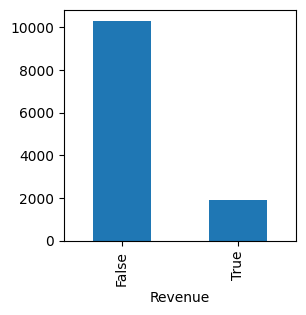

--------------------------------------------------


,count
Weekend,
False,9346
True,2859


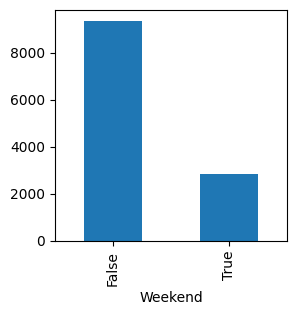

--------------------------------------------------


,count
VisitorType,
Returning_Visitor,10431
New_Visitor,1693
Other,81


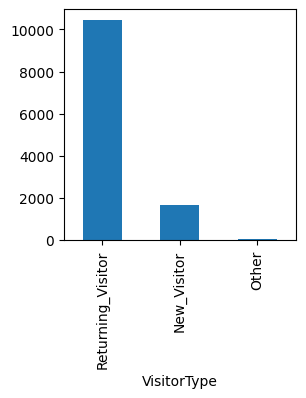

--------------------------------------------------


,count
SpecialDay,
0.0,10956
0.6,350
0.8,324
0.4,243
0.2,178
1.0,154


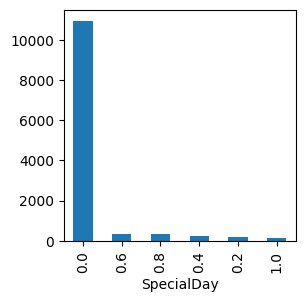

--------------------------------------------------


,count
OperatingSystems,
2,6541
1,2549
3,2530
4,478
8,75
6,19
7,7
5,6


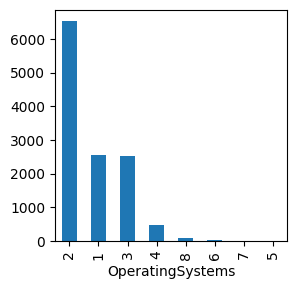

--------------------------------------------------


,count
Region,
1,4714
3,2379
4,1171
2,1128
6,801
7,758
9,505
8,431
5,318


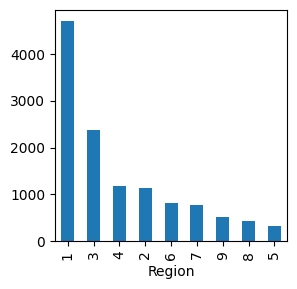

--------------------------------------------------


,count
Browser,
2,7883
1,2427
4,731
5,465
6,174
10,163
8,135
3,105
13,56


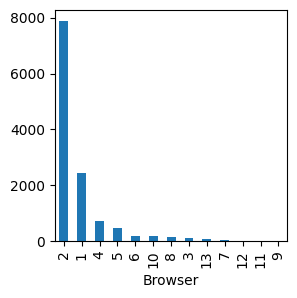

--------------------------------------------------


In [103]:
for column in categorical_cols:
    
    column_counts = df[column].value_counts()
    display(column_counts.to_frame())
    
    column_counts.plot(kind='bar', figsize=(3,3))
    plt.show()
    print("-" * 50)

In [105]:
df.to_csv("cleaned.csv")